In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('train.csv')

In [ ]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
df.shape

(1460, 81)

In [ ]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [ ]:
(df.isnull().sum()/len(df)*100).sort_values(ascending=False).head(10)

,0
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageQual,5.547945
GarageFinish,5.547945
GarageType,5.547945


In [ ]:
df.drop_duplicates()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [ ]:
cols_to_drop = [
    'PoolQC',
    'MiscFeature',
    'Alley',
    'Fence',
    'MasVnrType',
    'FireplaceQu',
    'GarageQual',
    'GarageCond',
    'GarageFinish',
    'GarageYrBlt',
    'GarageType',
    'BsmtFinType2',
    'BsmtExposure',
    'BsmtFinType1',
    'BsmtCond',
    'BsmtQual',
    'Id','LotFrontage','MasVnrArea','Street'
]

df.drop(columns=cols_to_drop, inplace=True)

In [ ]:
df.head()

,MSSubClass,MSZoning,LotArea,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,8450,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,9600,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,11250,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,9550,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,14260,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [ ]:
df['LandSlope'].value_counts()

,count
LandSlope,
Gtl,1382
Mod,65
Sev,13


<Axes: xlabel='SalePrice', ylabel='Count'>

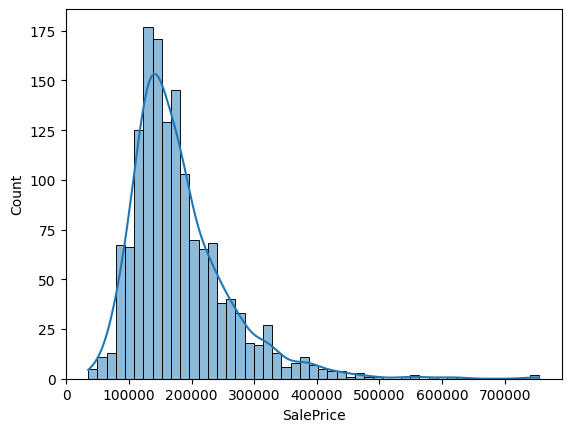

In [ ]:
sns.histplot(df['SalePrice'],kde = True)

In [ ]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0
Electrical,1


In [ ]:
df['Electrical'].fillna(
    df['Electrical'].mode()[0],
    inplace=True
)

In [ ]:
df.isnull().sum()

,0
MSSubClass,0
MSZoning,0
LotArea,0
LotShape,0
LandContour,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [ ]:
df['SalePrice'] = np.log1p(df['SalePrice'])

In [ ]:
df['SalePrice'].skew()

np.float64(0.12134661989685333)

In [ ]:
corr = df.corr(numeric_only=True)

corr['SalePrice'].sort_values(ascending=False)[1:15]

,SalePrice
OverallQual,0.817185
GrLivArea,0.700927
GarageCars,0.680625
GarageArea,0.650888
TotalBsmtSF,0.612134
1stFlrSF,0.596981
FullBath,0.594771
YearBuilt,0.586570
YearRemodAdd,0.565608
TotRmsAbvGrd,0.534422


<Axes: >

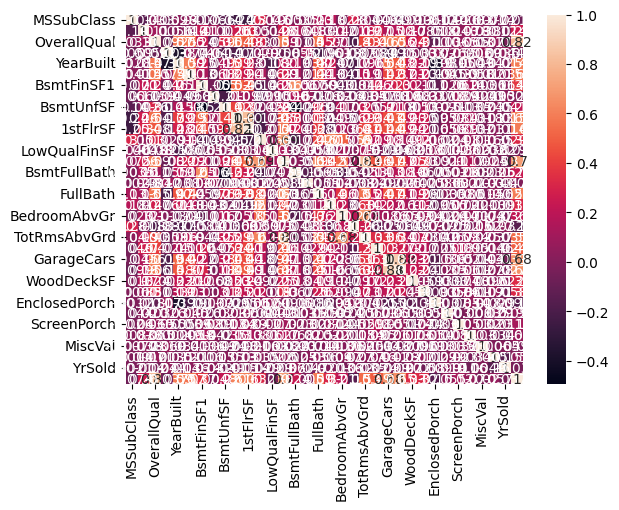

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [ ]:
corr_matrix = df.corr(numeric_only=True)

In [ ]:

upper = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr = [
    col
    for col in upper.columns
    if any(upper[col] > 0.8)
]

high_corr

['1stFlrSF', 'TotRmsAbvGrd', 'GarageArea', 'SalePrice']

In [ ]:
cat_cols = df.select_dtypes(include = 'object').columns

In [ ]:
for col in cat_cols:
   print(col, ":", df[col].nunique())

MSZoning : 5
LotShape : 4
LandContour : 4
Utilities : 2
LotConfig : 5
LandSlope : 3
Neighborhood : 25
Condition1 : 9
Condition2 : 8
BldgType : 5
HouseStyle : 8
RoofStyle : 6
RoofMatl : 8
Exterior1st : 15
Exterior2nd : 16
ExterQual : 4
ExterCond : 5
Foundation : 6
Heating : 6
HeatingQC : 5
CentralAir : 2
Electrical : 5
KitchenQual : 4
Functional : 7
PavedDrive : 3
SaleType : 9
SaleCondition : 6


In [ ]:
df = pd.get_dummies(df,drop_first=True,dtype = int)

In [ ]:
df.head()

,MSSubClass,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,8450,7,5,2003,2003,706,0,150,856,...,0,0,0,0,1,0,0,0,1,0
1,20,9600,6,8,1976,1976,978,0,284,1262,...,0,0,0,0,1,0,0,0,1,0
2,60,11250,7,5,2001,2002,486,0,434,920,...,0,0,0,0,1,0,0,0,1,0
3,70,9550,7,5,1915,1970,216,0,540,756,...,0,0,0,0,1,0,0,0,0,0
4,60,14260,8,5,2000,2000,655,0,490,1145,...,0,0,0,0,1,0,0,0,1,0


In [ ]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,root_mean_squared_error

model = LinearRegression()
model.fit(X_train_scaled, y_train)

LinearRegression()

In [ ]:
y_pred= model.predict(X_test_scaled)

In [ ]:
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R-squared:", r2_score(y_test, y_pred))
print("Root Mean Squared Error:", root_mean_squared_error(y_test, y_pred))


Mean Squared Error: 0.04209393517804255
R-squared: 0.7744294936953311
Root Mean Squared Error: 0.20516806568772478


In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
rf_pred = rf.predict(X_test)

In [ ]:
print("Mean Squared Error:", mean_squared_error(y_test, rf_pred))
print("R-squared:", r2_score(y_test, rf_pred))
print("Root Mean Squared Error:", root_mean_squared_error(y_test, rf_pred))


Mean Squared Error: 0.02120077615214699
R-squared: 0.8863905265576995
Root Mean Squared Error: 0.14560486307863138


In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    random_state=42,
    learning_rate=0.1,
    max_depth=3
)

xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
xgb_pred = xgb.predict(X_test)

In [ ]:
print("Mean Squared Error:", mean_squared_error(y_test, xgb_pred))
print("R-squared:", r2_score(y_test, xgb_pred))
print("Root Mean Squared Error:", root_mean_squared_error(y_test,xgb_pred))

Mean Squared Error: 0.018616153177414604
R-squared: 0.9002408522768587
Root Mean Squared Error: 0.13644102453959586


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1],
    'colsample_bytree': [0.8, 0.9, 1]
}
search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=params,
    scoring='r2',
    cv=5,
    n_jobs=-1
)
search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          max_delta_step=None, max_depth=3,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None, n_estimators=100,
                                          n_jobs=None, num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9, 1],
                                        'learning_rate': [0.01, 0.05, 0.1],
                                        'max_depth': [3, 4, 5, 6, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.8, 0.9, 1]},
                   scoring='r2')

In [ ]:
search.best_params_

{'subsample': 0.8,
 'n_estimators': 200,
 'max_depth': 5,
 'learning_rate': 0.05,
 'colsample_bytree': 0.8}

In [ ]:
xgb_best = search.best_estimator_

In [ ]:
best_pred = xgb_best.predict(X_test)

In [ ]:
print("Mean Squared Error:", mean_squared_error(y_test, best_pred))
print("R-squared:", r2_score(y_test, best_pred))
print("Root Mean Squared Error:", root_mean_squared_error(y_test,best_pred))

Mean Squared Error: 0.017845885000722105
R-squared: 0.9043685201195538
Root Mean Squared Error: 0.1335884912734705


In [ ]:
importance = pd.DataFrame(
    data={
        'Attribute': X_train.columns,
        'Importance': xgb_best.feature_importances_
    }
)
importance.sort_values(by='Importance', ascending=False)

,Attribute,Importance
2,OverallQual,0.194669
143,ExterQual_TA,0.133552
22,GarageCars,0.086476
162,CentralAir_Y,0.050154
13,GrLivArea,0.044930
...,...,...
178,SaleType_CWD,0.000000
179,SaleType_Con,0.000000
180,SaleType_ConLD,0.000000
186,SaleCondition_AdjLand,0.000000


In [ ]:
train_pred = search.best_estimator_.predict(X_train)

test_pred = search.best_estimator_.predict(X_test)

print(
    "Train R2:",
    r2_score(y_train, train_pred)
)

print(
    "Test R2:",
    r2_score(y_test, test_pred)
)

Train R2: 0.9865433395685014
Test R2: 0.9043685201195538


In [ ]:
y_test_actual = np.expm1(y_test)

pred_actual= np.expm1(best_pred)

In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test_actual.values,
    'Predicted': pred_actual
})

comparison.head()

,Actual,Predicted
0,154500.0,141875.046875
1,325000.0,323139.187500
2,115000.0,116302.070312
3,159000.0,159254.156250
4,315500.0,313693.125000


<Axes: xlabel='Actual', ylabel='Predicted'>

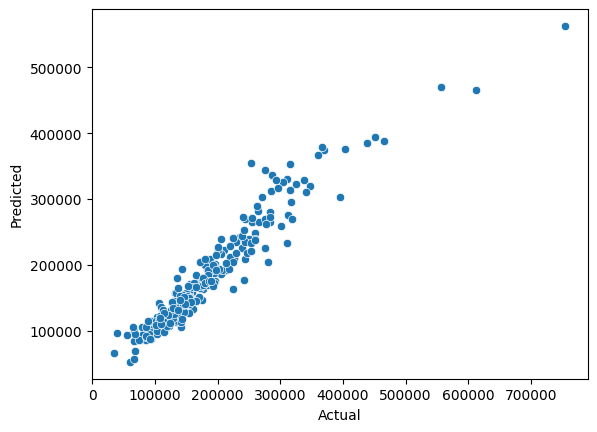

In [ ]:
sns.scatterplot(x='Actual', y='Predicted', data=comparison)

<Axes: xlabel='Actual', ylabel='None'>

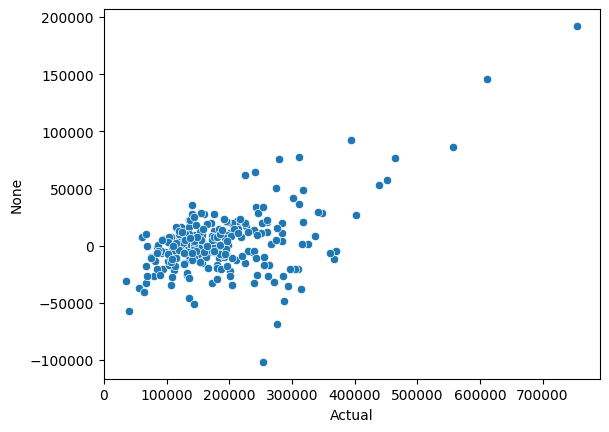

In [ ]:
residuals = comparison['Actual'] - comparison['Predicted']

sns.scatterplot(x=comparison['Actual'], y=residuals)

In [ ]:
import joblib
joblib.dump(search.best_estimator_, 'xgb_model.pkl')


['xgb_model.pkl']

In [ ]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']